<a href="https://colab.research.google.com/github/sarbarup/HFVRP/blob/SB/Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Optimized Logistics: Capacitated Vehicle Routing with Heterogeneous Fleet

## 1. Introduction & Problem Statement

This analysis addresses a **Capacitated Vehicle Routing Problem (CVRP)** involving a heterogeneous fleet of 15 vehicles serving 50 distinct customer locations from a central depot. Each location has a specific demand in kilograms, and each vehicle has varying characteristics:

*   **Capacity**: Different maximum load (kg).
*   **Speed**: Different top speeds (km/h).
*   **Range**: Different maximum travel distances (meters), determined by fuel tank size.
*   **Hourly Rate**: Different driver hourly costs ($).

The primary objective of this optimization is to **minimize the total operational cost**, which is a combined metric of total distance traveled and total driver time across all routes.

## 2. Methodology: Google OR-Tools

Google's OR-Tools library, a powerful suite for solving optimization problems, was employed. Specifically, the Constraint Solver was configured to handle:

*   **Distance Calculation**: Haversine formula for pure great-circle distances (in meters) between geographic coordinates.
*   **Heterogeneous Costs**: A custom cost callback for each vehicle, combining distance and time (derived from speed and hourly rate).
*   **Constraints**:
    *   **Capacity**: Each vehicle's total load must not exceed its maximum capacity.
    *   **Range**: Each vehicle's total travel distance must not exceed its maximum range (fuel capacity).
    *   **Time**: Each vehicle's total travel time is implicitly constrained by its max range and speed.

The solver utilized `PATH_CHEAPEST_ARC` for its first solution strategy and `GUIDED_LOCAL_SEARCH` as its local search metaheuristic, with a time limit of 5 seconds for solution finding.

## 3. Key Results & Solution Summary

The optimization successfully generated routes for 13 out of 15 available vehicles. Below is an overall summary of the solution:

*   **Vehicles Used**: 13 out of 15 available
*   **Total Stops**: 50
*   **Total Distance**: 38,118.7 km
*   **Total Time**: 423.54 hours
*   **Total Cost**: $38,133,046.57
*   **Total Load Delivered**: 94,419 kg

**Average Performance Metrics per Used Vehicle:**

*   **Average Load Utilization**: 92.4%
*   **Average Range Utilization**: 41.2%
*   **Average Stops per Vehicle**: 3.8
*   **Average Distance per Vehicle**: 2,932.2 km
*   **Average Cost per Vehicle**: $2,933,311.27

## 4. Vehicle Performance Highlights

### Load Utilization

The vehicles demonstrate high load utilization, with an average of 92.4%. This indicates efficient packing and allocation of demand to vehicles, ensuring that most vehicles operate close to their carrying capacity. Some vehicles, like Vehicle 0 (99.9%), Vehicle 5 (99.6%), and Vehicle 8 (96.4%), show exceptionally high utilization.

### Range Utilization

Range utilization averages 41.2%, suggesting that while routes are optimized for cost, vehicles generally have ample range remaining. This could indicate opportunities to potentially extend routes or serve more distant locations if other constraints permit, or a robust safety margin for unexpected delays/detours. Vehicle 1 and 3 show higher range utilization (90.7% and 95.8% respectively), indicating they are pushing closer to their max range.

### Cost Distribution

The total cost is distributed among the 13 used vehicles, with individual route costs varying based on distance, time, and the specific vehicle's hourly rate and speed. Vehicles 1 and 3 incur the highest costs due to the extensive distances covered. Vehicles 12 and 14 have significantly lower costs, suggesting shorter routes or less complex operational demands.

### Time and Stops

The total time for routes ranges from very short trips (e.g., Vehicle 12 at 0.08 hours for 1 stop) to much longer ones (e.g., Vehicle 1 at 75.57 hours for 5 stops). The average number of stops per vehicle is 3.8, showing a balanced distribution of service points.

## 5. Visualizations

(A map illustrating the optimized routes, along with bar charts for load utilization, range utilization, cost per vehicle, time per vehicle, and stops per vehicle, has been generated and saved as `cvrp_solution.png` in `/content/CVRP_Sol`.)

## 6. Conclusion & Next Steps

The optimized solution effectively balances demand with heterogeneous vehicle capabilities to minimize total cost. The high load utilization highlights efficiency in resource allocation, while the lower average range utilization suggests flexibility. Further analysis could explore:

*   **Dynamic Routing**: Incorporating real-time traffic or new orders.
*   **Time Windows**: Adding constraints for specific delivery/pickup times.
*   **Sensitivity Analysis**: Understanding how changes in demand, fuel prices, or vehicle availability impact the optimal solution.
*   **Backhauls/Pickups**: Extending the model to include return trips or collection points.

In [1]:
!pip install ortools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.7/27.7 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.1/321.1 kB 15.2 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, but you have protobuf 6.31.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.31.1 which is incompatibl

First, let's specify the name of the directory you want to create and then make sure it doesn't already exist before creating it.

In [6]:
import os

# Define the name of the new folder
new_folder_name = 'CVRP_Sol'

# Get the current working directory (optional, for context)
current_directory = os.getcwd()
print(f"Current working directory: {current_directory}")

# Construct the full path for the new folder
new_folder_path = os.path.join(current_directory, new_folder_name)

# Check if the folder already exists
if not os.path.exists(new_folder_path):
    # Create the new folder
    os.makedirs(new_folder_path)
    print(f"Folder '{new_folder_name}' created successfully at: {new_folder_path}")
else:
    print(f"Folder '{new_folder_name}' already exists at: {new_folder_path}")

Current working directory: /content
Folder 'CVRP_Sol' created successfully at: /content/CVRP_Sol


You can change `my_new_folder` to any name you prefer for your directory. This folder will be created in the root of your Colab environment by default.

### Part 1: Initial Setup - Imports and Global Constants

This section imports all necessary libraries and defines global constants used throughout the Capacitated Vehicle Routing Problem (CVRP) model. These constants include scaling factors, problem dimensions (number of locations, vehicles), and geographical data like the Earth's radius for distance calculations.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp
import math
import os

# Define the constants
COST_SCALE_FACTOR = 1000
TIME_SCALE_FACTOR = 100
NUM_LOCATIONS = 50
NUM_NODES = 51 # NUM_LOCATIONS + 1 (for depot)
NUM_VEHICLES = 15
EARTH_RADIUS_M = 6371000

### Part 2: Data Model Creation

This part defines helper functions to prepare the input data for the OR-Tools solver. It includes a `haversine_distance` function to calculate distances between coordinates and `create_data_model` which structures all problem-specific data, such as locations, demands, vehicle capacities, speeds, hourly rates, and the pre-calculated distance matrix.

In [9]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate the pure great-circle distance between two points
    on the earth (specified in decimal degrees) using the Haversine formula.
    Returns distance in meters.
    """
    # Convert degrees to radians
    lat1_rad = math.radians(lat1)
    lon1_rad = math.radians(lon1)
    lat2_rad = math.radians(lat2)
    lon2_rad = math.radians(lon2)

    dlon = lon2_rad - lon1_rad
    dlat = lat2_rad - lat1_rad

    a = math.sin(dlat / 2)**2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(dlon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    distance_m = EARTH_RADIUS_M * c

    # Returning pure great-circle distance (no road factor applied)
    return int(round(distance_m))


def create_data_model():
    """Stores the data for the problem using provided location and vehicle inputs."""
    data = {}
    data["depot"] = 0
    data["num_vehicles"] = NUM_VEHICLES

    data["locations"] = [
        "Cincinnati, OH (Depot)", "Albany, NY", "Albany, OR", "Baton Rouge, LA", "Birmingham, AL",
        "Boston, MA", "Buffalo, NY", "Cambridge, MA", "Charlotte, NC", "Chicago, IL",
        "Colorado Springs, CO", "Columbus, OH", "Dallas, TX", "Davis, CA", "Decatur, IL",
        "Denver, CO", "Detroit, MI", "Forks, WA", "Frankfort, KY", "Grand Rapids, MI",
        "Hilton Head, SC", "Indianapolis, IN", "Key West, FL", "Las Vegas, NV", "Lexington, KY",
        "Lexington, SC", "Lincoln, NE", "Los Angeles, CA", "Louisville, KY", "Memphis, TN",
        "Miami, FL", "Nashville, TN", "New York City, NY", "Newport, KY", "Omaha, NE",
        "Oakland, CA", "Oshkosh, WI", "Philadelphia, PA", "Pittsburgh, PA", "Portland, ME",
        "Portland, OR", "Salem, MA", "Salt Lake City, UT", "San Francisco, CA", "Santa Claus, IN",
        "Seattle, WA", "Spokane, WA", "St Louis, MO", "Tampa, FL", "Toronto, Canada",
        "Washington, DC (1)"
    ]

    COORDINATES = [
        (39.10, -84.51), # 0 Cincinnati, OH (Depot)
        (42.65, -73.76), # 1 Albany, NY
        (44.63, -123.10), # 2 Albany, OR
        (30.45, -91.19), # 3 Baton Rouge, LA
        (33.52, -86.80), # 4 Birmingham, AL
        (42.36, -71.06), # 5 Boston, MA
        (42.89, -78.87), # 6 Buffalo, NY
        (42.37, -71.11), # 7 Cambridge, MA
        (35.23, -80.84), # 8 Charlotte, NC
        (41.88, -87.63), # 9 Chicago, IL
        (38.83, -104.82), # 10 Colorado Springs, CO
        (39.96, -83.00), # 11 Columbus, OH
        (32.78, -96.80), # 12 Dallas, TX
        (38.54, -121.74), # 13 Davis, CA
        (39.84, -89.00), # 14 Decatur, IL
        (39.74, -104.99), # 15 Denver, CO
        (42.33, -83.05), # 16 Detroit, MI
        (47.96, -124.38), # 17 Forks, WA
        (38.20, -84.87), # 18 Frankfort, KY
        (42.96, -85.67), # 19 Grand Rapids, MI
        (32.22, -80.75), # 20 Hilton Head, SC
        (39.77, -86.16), # 21 Indianapolis, IN
        (24.56, -81.78), # 22 Key West, FL
        (36.17, -115.14), # 23 Las Vegas, NV
        (38.00, -84.50), # 24 Lexington, KY
        (34.00, -81.23), # 25 Lexington, SC
        (40.81, -96.70), # 26 Lincoln, NE
        (34.05, -118.24), # 27 Los Angeles, CA
        (38.25, -85.76), # 28 Louisville, KY
        (35.15, -90.05), # 29 Memphis, TN
        (25.76, -80.19), # 30 Miami, FL
        (36.17, -86.78), # 31 Nashville, TN
        (40.71, -74.01), # 32 New York City, NY
        (39.08, -84.48), # 33 Newport, KY
        (41.26, -96.00), # 34 Omaha, NE
        (37.80, -122.27), # 35 Oakland, CA
        (44.02, -88.54), # 36 Oshkosh, WI
        (39.95, -75.17), # 37 Philadelphia, PA
        (40.44, -80.00), # 38 Pittsburgh, PA
        (43.66, -70.26), # 39 Portland, ME
        (45.52, -122.68), # 40 Portland, OR
        (42.52, -70.89), # 41 Salem, MA
        (40.76, -111.89), # 42 Salt Lake City, UT
        (37.77, -122.42), # 43 San Francisco, CA
        (38.12, -86.92), # 44 Santa Claus, IN
        (47.61, -122.33), # 45 Seattle, WA
        (47.66, -117.43), # 46 Spokane, WA
        (38.63, -90.20), # 47 St Louis, MO
        (27.95, -82.46), # 48 Tampa, FL
        (43.65, -79.38), # 49 Toronto, Canada
        (38.90, -77.04)  # 50 Washington, DC (1)
    ]
    data["coordinates"] = COORDINATES

    data["demands"] = [
        0,       # 0: Cincinnati, OH (Depot/Warehouse)
        3120,    # 1: Albany, ID
        1296,    # 2: Albany, NY
        2707,    # 3: Baton Rouge, LA
        1242,    # 4: Birmingham, AL
        2863,    # 5: Boston, MA
        667,     # 6: Buffalo, NY
        1577,    # 7: Cambridge, MA
        1855,    # 8: Charlotte, NC
        2406,    # 9: Chicago, IL
        1991,    # 10: Colorado Springs, CO
        2454,    # 11: Columbus, OH
        917,     # 12: Dallas, TX
        969,     # 13: Davis, CA
        1562,    # 14: Decatur, IL
        3869,    # 15: Denver, CO
        3494,    # 16: Detroit, MI
        1264,    # 17: Forks, WA
        95,      # 18: Frankfort, KY
        1281,    # 19: Grand Rapids, MI
        952,     # 20: Hilton Head, SC
        591,     # 21: Indianapolis, IN
        2034,    # 22: Key West, FL
        441,     # 23: Las Vegas, NV
        2152,    # 24: Lexington, KY
        4502,    # 25: Lexington, SC
        1999,    # 26: Lincoln, NE
        2372,    # 27: Los Angeles, CA
        1420,    # 28: Louisville, KY
        3715,    # 29: Memphis, TN
        1445,    # 30: Miami, FL
        1044,    # 31: Nashville, TN
        2255,    # 32: New York City, NY
        2448,    # 33: Newport, KY
        2525,    # 34: Omaha, NE
        2109,    # 35: Oakland, CA (Orlando, FL)
        3158,    # 36: Oshkosh, WI
        3290,    # 37: Philadelphia, PA
        1126,    # 38: Pittsburgh, PA
        1345,    # 39: Portland, ME
        4188,    # 40: Portland, OR
        169,     # 41: Salem, MA
        487,     # 42: Salt Lake City, UT
        1928,    # 43: San Francisco, CA
        2419,    # 44: Santa Claus, IN
        1733,    # 45: Seattle, WA
        1638,    # 46: Spokane, WA
        722,     # 47: St Louis, MO
        892,     # 48: Tampa, FL
        2893,    # 49: Toronto, Canada
        798      # 50: Washington, DC (1)
    ]

    CAPACITIES_KG = [10000, 10000, 10000, 10000, 10000, 7500, 7500, 7500, 7500, 6000, 6000, 6000, 4000, 4000, 4000]
    HOURLY_RATES = [33, 33, 40, 29, 33, 27, 28, 28, 25, 26, 22, 24, 22, 23, 22]
    TOP_SPEEDS_KMH = [80, 80, 80, 80, 80, 90, 90, 90, 90, 90, 90, 90, 105, 105, 105]
    FUEL_TANKS_GALLON = [150, 150, 150, 145, 150, 120, 130, 130, 130, 130, 125, 125, 130, 135, 135]

    data["vehicle_speeds"] = [int(round(s * 1000 / 60)) for s in TOP_SPEEDS_KMH]

    GALLON_TO_METER_RANGE = 50000
    data["max_range"] = [g * GALLON_TO_METER_RANGE for g in FUEL_TANKS_GALLON]

    data["vehicle_capacities"] = CAPACITIES_KG
    data["driver_hourly_rate"] = HOURLY_RATES

    distance_matrix = []
    for i in range(NUM_NODES):
        row = []
        for j in range(NUM_NODES):
            if i == j:
                distance = 0
            else:
                lat1, lon1 = COORDINATES[i]
                lat2, lon2 = COORDINATES[j]
                distance = haversine_distance(lat1, lon1, lat2, lon2)
            row.append(distance)
        distance_matrix.append(row)

    data["distance_matrix"] = distance_matrix

    return data

### Part 3: Solution Reporting Functions

This section contains functions dedicated to presenting the solution in a readable format. `print_solution` outputs a detailed text summary of each vehicle's route, including distance, load, time, and cost. `create_solution_tables` generates pandas DataFrames for route summaries and detailed stops, which are useful for further analysis and visualization. `create_vehicle_summary_table` provides a quick overview of vehicle specifications.

In [10]:
def print_solution(data, manager, routing, solution):
    """Prints solution on console, including cost, distance, time, and range."""
    total_scaled_cost = solution.ObjectiveValue()

    range_dimension = routing.GetDimensionOrDie("Range")
    time_dimension = routing.GetDimensionOrDie("Time")

    total_distance = 0
    total_load = 0
    total_time_minutes = 0.0
    total_unscaled_cost = 0.0

    print(f"Objective (Total SCALED Cost): {total_scaled_cost}")
    print("--------------------------------------------------")
    print(f"Number of Locations: {NUM_LOCATIONS} (plus 1 Depot = {NUM_NODES} nodes total)")
    print(f"Number of Vehicles: {NUM_VEHICLES}")
    print("Vehicles have heterogeneous speeds and costs. Distance is pure Haversine (m).")
    print("--------------------------------------------------")

    for vehicle_id in range(data["num_vehicles"]):
        index = routing.Start(vehicle_id)

        if solution.Value(routing.NextVar(index)) == routing.End(vehicle_id):
            continue

        hourly_rate = data['driver_hourly_rate'][vehicle_id]
        vehicle_speed = data["vehicle_speeds"][vehicle_id]
        rate_per_min = hourly_rate / 60.0

        plan_output = f"--- Route for Vehicle {vehicle_id} ---\n"
        plan_output += f"  Capacity: {data['vehicle_capacities'][vehicle_id]}kg, Max Range: {data['max_range'][vehicle_id]}m\n"
        plan_output += f"  Rate: ${hourly_rate}/hr, Speed: {vehicle_speed}m/min\n"
        plan_output += "Route:\n"

        route_distance = 0
        route_load = 0
        route_cost = 0.0

        route_nodes = []
        while not routing.IsEnd(index):
            node_index = manager.IndexToNode(index)

            if node_index != data["depot"]:
                route_load += data["demands"][node_index]

            route_nodes.append(f" {data['locations'][node_index]} Load({route_load}kg)")

            previous_index = index
            index = solution.Value(routing.NextVar(index))

            from_node = manager.IndexToNode(previous_index)
            to_node = manager.IndexToNode(index)
            distance = data["distance_matrix"][from_node][to_node]
            route_distance += distance

            if distance > 0 and vehicle_speed > 0:
                time_minutes = distance / vehicle_speed
                cost = distance + (time_minutes * rate_per_min)
                route_cost += cost

        route_nodes.append(f" {data['locations'][manager.IndexToNode(index)]} Load({route_load}kg)")
        plan_output += " -> ".join(route_nodes) + "\n"

        route_time_scaled = solution.Value(time_dimension.CumulVar(index))
        route_time_minutes = route_time_scaled / TIME_SCALE_FACTOR

        plan_output += f"Total Distance: {route_distance}m (Range Limit: {data['max_range'][vehicle_id]}m)\n"
        plan_output += f"Total Load: {route_load}kg\n"
        plan_output += f"Total Time: {route_time_minutes:.2f} minutes\n"
        plan_output += f"Total Route Cost: ${route_cost:.2f}\n\n"
        print(plan_output)

        total_distance += route_distance
        total_load += route_load
        total_time_minutes += route_time_minutes
        total_unscaled_cost += route_cost

    print(f"Total distance of all routes: {total_distance}m")
    print(f"Total load of all routes: {total_load}kg")
    print(f"Total time of all routes: {total_time_minutes:.2f} minutes")
    print(f"Total UN-SCALED cost: ${total_unscaled_cost:.2f}")

def create_solution_tables(data, manager, routing, solution):
    """Create comprehensive tables from the solution"""

    range_dimension = routing.GetDimensionOrDie("Range")
    time_dimension = routing.GetDimensionOrDie("Time")
    capacity_dimension = routing.GetDimensionOrDie("Capacity")

    routes_data = []
    node_visits = []

    for vehicle_id in range(data["num_vehicles"]):
        index = routing.Start(vehicle_id)

        if solution.Value(routing.NextVar(index)) == routing.End(vehicle_id):
            continue

        hourly_rate = data['driver_hourly_rate'][vehicle_id]
        vehicle_speed = data["vehicle_speeds"][vehicle_id]
        rate_per_min = hourly_rate / 60.0

        route_distance = 0
        route_load = 0
        route_cost = 0.0
        route_nodes = []
        stop_number = 0

        while not routing.IsEnd(index):
            node_index = manager.IndexToNode(index)

            if node_index != data["depot"]:
                route_load += data["demands"][node_index]
                stop_number += 1

                node_visits.append({
                    'Vehicle': vehicle_id,
                    'Stop': stop_number,
                    'Location': data['locations'][node_index],
                    'Demand_kg': data["demands"][node_index],
                    'Cumulative_Load_kg': route_load,
                    'Latitude': data['coordinates'][node_index][0],
                    'Longitude': data['coordinates'][node_index][1]
                })

            previous_index = index
            index = solution.Value(routing.NextVar(index))

            from_node = manager.IndexToNode(previous_index)
            to_node = manager.IndexToNode(index)
            distance = data["distance_matrix"][from_node][to_node]
            route_distance += distance

            if distance > 0 and vehicle_speed > 0:
                time_minutes = distance / vehicle_speed
                cost = distance + (time_minutes * rate_per_min)
                route_cost += cost

        route_time_scaled = solution.Value(time_dimension.CumulVar(index))
        route_time_minutes = route_time_scaled / TIME_SCALE_FACTOR

        routes_data.append({
            'Vehicle_ID': vehicle_id,
            'Capacity_kg': data['vehicle_capacities'][vehicle_id],
            'Speed_m_per_min': vehicle_speed,
            'Speed_km_per_h': round(vehicle_speed * 60 / 1000, 1),
            'Hourly_Rate_$': hourly_rate,
            'Max_Range_m': data['max_range'][vehicle_id],
            'Max_Range_km': round(data['max_range'][vehicle_id] / 1000, 1),
            'Stops': stop_number,
            'Total_Load_kg': route_load,
            'Load_Utilization_%': round((route_load / data['vehicle_capacities'][vehicle_id]) * 100, 1),
            'Total_Distance_m': route_distance,
            'Total_Distance_km': round(route_distance / 1000, 1),
            'Distance_Utilization_%': round((route_distance / data['max_range'][vehicle_id]) * 100, 1),
            'Total_Time_min': round(route_time_minutes, 1),
            'Total_Time_hours': round(route_time_minutes / 60, 2),
            'Total_Cost_$': round(route_cost, 2)
        })

    routes_df = pd.DataFrame(routes_data)
    visits_df = pd.DataFrame(node_visits)

    return routes_df, visits_df


def create_vehicle_summary_table(data):
    """Create a table of vehicle specifications"""
    vehicle_data = []

    for i in range(data["num_vehicles"]):
        vehicle_data.append({
            'Vehicle_ID': i,
            'Capacity_kg': data['vehicle_capacities'][i],
            'Speed_km_h': round(data['vehicle_speeds'][i] * 60 / 1000, 1),
            'Hourly_Rate_$': data['driver_hourly_rate'][i],
            'Max_Range_km': round(data['max_range'][i] / 1000, 1),
            'Max_Time_hours': round((data['max_range'][i] / data['vehicle_speeds'][i]) / 60, 1)
        })

    return pd.DataFrame(vehicle_data)

### Part 4: Visualization and Summary Statistics

This part defines functions for visualizing the routes and presenting overall summary statistics. `visualize_routes` uses `matplotlib` and `seaborn` to create a multi-panel plot showing the vehicle routes on a map, and bar charts for load utilization, range utilization, cost, time, and stops per vehicle. `print_summary_statistics` calculates and displays key aggregate metrics of the entire solution.

In [11]:
def visualize_routes(data, visits_df, routes_df):
    """Create visualizations of the solution"""

    sns.set_style("whitegrid")

    fig = plt.figure(figsize=(20, 12))

    ax1 = plt.subplot(2, 3, 1)

    depot_coords = data['coordinates'][0]
    ax1.scatter(depot_coords[1], depot_coords[0], c='red', s=300, marker='s',
                label='Depot', zorder=5, edgecolors='black', linewidths=2)

    colors = plt.cm.tab20(np.linspace(0, 1, len(routes_df)))

    for idx, vehicle_id in enumerate(routes_df['Vehicle_ID']):
        vehicle_visits = visits_df[visits_df['Vehicle'] == vehicle_id]

        if len(vehicle_visits) > 0:
            lons = [depot_coords[1]] + vehicle_visits['Longitude'].tolist() + [depot_coords[1]]
            lats = [depot_coords[0]] + vehicle_visits['Latitude'].tolist() + [depot_coords[0]]
            ax1.plot(lons, lats, c=colors[idx], linewidth=1.5, alpha=0.6, zorder=1)

            ax1.scatter(vehicle_visits['Longitude'], vehicle_visits['Latitude'],
                       c=[colors[idx]], s=100, alpha=0.7, zorder=3, edgecolors='black', linewidths=0.5)

    ax1.set_xlabel('Longitude', fontsize=10)
    ax1.set_ylabel('Latitude', fontsize=10)
    ax1.set_title('Vehicle Routes Map', fontsize=12, fontweight='bold')
    ax1.legend(loc='best', fontsize=8)
    ax1.grid(True, alpha=0.3)

    ax2 = plt.subplot(2, 3, 2)
    vehicles = routes_df['Vehicle_ID'].astype(str)
    load_util = routes_df['Load_Utilization_%']
    bars = ax2.barh(vehicles, load_util, color=colors[:len(routes_df)])
    ax2.axvline(x=100, color='red', linestyle='--', linewidth=2, label='Max Capacity')
    ax2.set_xlabel('Load Utilization (%)', fontsize=10)
    ax2.set_ylabel('Vehicle ID', fontsize=10)
    ax2.set_title('Vehicle Load Utilization', fontsize=12, fontweight='bold')
    ax2.set_xlim(0, 110)
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax2.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.1f}%',
                ha='left', va='center', fontsize=8)
    ax2.legend()

    ax3 = plt.subplot(2, 3, 3)
    dist_util = routes_df['Distance_Utilization_%']
    bars = ax3.barh(vehicles, dist_util, color=colors[:len(routes_df)])
    ax3.axvline(x=100, color='red', linestyle='--', linewidth=2, label='Max Range')
    ax3.set_xlabel('Range Utilization (%)', fontsize=10)
    ax3.set_ylabel('Vehicle ID', fontsize=10)
    ax3.set_title('Vehicle Range Utilization', fontsize=12, fontweight='bold')
    ax3.set_xlim(0, 110)
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax3.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.1f}%',
                ha='left', va='center', fontsize=8)
    ax3.legend()

    ax4 = plt.subplot(2, 3, 4)
    costs = routes_df['Total_Cost_$']
    bars = ax4.bar(vehicles, costs, color=colors[:len(routes_df)])
    ax4.set_xlabel('Vehicle ID', fontsize=10)
    ax4.set_ylabel('Total Cost ($)', fontsize=10)
    ax4.set_title('Cost per Vehicle', fontsize=12, fontweight='bold')
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2, height, f'${height:.0f}',
                ha='center', va='bottom', fontsize=8)
    ax4.grid(True, alpha=0.3, axis='y')

    ax5 = plt.subplot(2, 3, 5)
    times = routes_df['Total_Time_hours']
    bars = ax5.bar(vehicles, times, color=colors[:len(routes_df)])
    ax5.set_xlabel('Vehicle ID', fontsize=10)
    ax5.set_ylabel('Total Time (hours)', fontsize=10)
    ax5.set_title('Time per Vehicle', fontsize=12, fontweight='bold')
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2, height, f'{height:.1f}h',
                ha='center', va='bottom', fontsize=8)
    ax5.grid(True, alpha=0.3, axis='y')

    ax6 = plt.subplot(2, 3, 6)
    stops = routes_df['Stops']
    bars = ax6.bar(vehicles, stops, color=colors[:len(routes_df)])
    ax6.set_xlabel('Vehicle ID', fontsize=10)
    ax6.set_ylabel('Number of Stops', fontsize=10)
    ax6.set_title('Stops per Vehicle', fontsize=12, fontweight='bold')
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}',
                ha='center', va='bottom', fontsize=8)
    ax6.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    return fig


def print_summary_statistics(routes_df):
    """Print overall summary statistics"""
    print("\n" + "="*80)
    print("OVERALL SOLUTION SUMMARY")
    print("="*80)

    print(f"\nVehicles Used: {len(routes_df)} out of {NUM_VEHICLES} available") # Changed to NUM_VEHICLES as all vehicles might not be used
    print(f"Total Stops: {routes_df['Stops'].sum()}")
    print(f"Total Distance: {routes_df['Total_Distance_km'].sum():,.1f} km")
    print(f"Total Time: {routes_df['Total_Time_hours'].sum():,.2f} hours")
    print(f"Total Cost: ${routes_df['Total_Cost_$'].sum():,.2f}")
    print(f"Total Load Delivered: {routes_df['Total_Load_kg'].sum():,.0f} kg")

    print(f"\nAverage Load Utilization: {routes_df['Load_Utilization_%'].mean():.1f}%")
    print(f"Average Range Utilization: {routes_df['Distance_Utilization_%'].mean():.1f}%")
    print(f"Average Stops per Vehicle: {routes_df['Stops'].mean():.1f}")
    print(f"Average Distance per Vehicle: {routes_df['Total_Distance_km'].mean():,.1f} km")
    print(f"Average Cost per Vehicle: ${routes_df['Total_Cost_$'].mean():,.2f}")

    print("\n" + "="*80)

### Part 5: OR-Tools Model Initialization

This section initializes the core components of the OR-Tools routing model. It instantiates the problem data using `create_data_model()`, creates a routing index manager (`pywrapcp.RoutingIndexManager`) to handle node indices and vehicle counts, and then creates the main routing model (`pywrapcp.RoutingModel`).

In [12]:
# Instantiate the data problem.
data = create_data_model()

# Create the routing index manager.
manager = pywrapcp.RoutingIndexManager(
    len(data["distance_matrix"]), data["num_vehicles"], data["depot"]
)

# Create Routing Model.
routing = pywrapcp.RoutingModel(manager)

### Part 6: Defining Callbacks and Adding Constraints (Capacity, Range, Time)

This is a crucial part where the problem's constraints and costs are defined for the OR-Tools solver. It includes:
-   **Distance Callback**: Calculates the distance between two nodes.
-   **Demand Callback**: Returns the demand at a specific node.
-   **Per-Vehicle Cost Callback**: Calculates the cost for each vehicle, considering distance and time based on its specific hourly rate and speed.
-   **Time Callback**: Calculates the travel time between nodes for each vehicle.
-   **Capacity Constraint**: Ensures no vehicle exceeds its maximum load capacity.
-   **Range Constraint**: Ensures no vehicle exceeds its maximum travel range.
-   **Time Dimension**: Adds a time dimension, incorporating heterogeneous vehicle speeds and max travel times.

In [13]:
# --- 1. Define Uniform Distance Callback (used for Range Constraint) ---
def distance_callback(from_index, to_index):
    """Returns the distance between the two nodes."""
    from_node = manager.IndexToNode(from_index)
    to_node = manager.IndexToNode(to_index)
    return data["distance_matrix"][from_node][to_node]

distance_transit_callback_index = routing.RegisterTransitCallback(distance_callback)

# --- 2. Define Demand Callback (used for Capacity Constraint) ---
def demand_callback(from_index):
    """Returns the demand of the node."""
    from_node = manager.IndexToNode(from_index)
    return data["demands"][from_node]

demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)

# Store the 15 different time callback indices (one for each vehicle speed)
time_callback_indices = []

# --- 3. Loop to Define Per-Vehicle Cost and Time Callbacks ---
for vehicle_id in range(data["num_vehicles"]):
    hourly_rate = data["driver_hourly_rate"][vehicle_id]
    vehicle_speed = data["vehicle_speeds"][vehicle_id]
    rate_per_min = hourly_rate / 60.0

    # 3a. Cost Callback (Distance + Time*Rate) with proper closure
    def make_cost_callback(rate_min, speed_m_per_min):
        def cost_callback(from_index, to_index):
            from_node = manager.IndexToNode(from_index)
            to_node = manager.IndexToNode(to_index)
            distance = data["distance_matrix"][from_node][to_node]

            if speed_m_per_min == 0:
                return 999999999 # Penalize infinite cost for zero speed
            time_minutes = distance / speed_m_per_min
            cost = distance + (time_minutes * rate_min)
            return int(round(cost * COST_SCALE_FACTOR))
        return cost_callback

    cost_callback_index = routing.RegisterTransitCallback(
        make_cost_callback(rate_per_min, vehicle_speed)
    )
    routing.SetArcCostEvaluatorOfVehicle(cost_callback_index, vehicle_id)

    # 3b. Time Dimension Callback with proper closure
    def make_time_callback(speed_m_per_min):
        def time_callback(from_index, to_index):
            from_node = manager.IndexToNode(from_index)
            to_node = manager.IndexToNode(to_index)
            distance = data["distance_matrix"][from_node][to_node]

            if speed_m_per_min == 0:
                return 999999999 # Penalize infinite time for zero speed
            time_minutes = distance / speed_m_per_min
            return int(round(time_minutes * TIME_SCALE_FACTOR))
        return time_callback

    time_index = routing.RegisterTransitCallback(
        make_time_callback(vehicle_speed)
    )
    time_callback_indices.append(time_index)

# --- 4. Constraint: Capacity (Load - KG) ---
routing.AddDimensionWithVehicleCapacity(
    demand_callback_index,
    0, # null capacity
    data["vehicle_capacities"],
    True, # Start cumul to zero
    "Capacity",
)

# --- 5. Constraint: Range (Fuel Tank Size - Max Distance) ---
routing.AddDimensionWithVehicleCapacity(
    distance_transit_callback_index,
    0, # null capacity
    data["max_range"],
    True, # Start cumul to zero
    "Range",
)

# --- 6. Dimension: Time (HETEROGENEOUS) - Derived from Fuel Tank Capacity ---
max_total_time_scaled = []
for vehicle_id in range(data["num_vehicles"]):
    max_range = data["max_range"][vehicle_id]
    vehicle_speed = data["vehicle_speeds"][vehicle_id]

    max_time_minutes = max_range / vehicle_speed if vehicle_speed > 0 else 0
    max_time_scaled = int(round(max_time_minutes * TIME_SCALE_FACTOR))
    max_total_time_scaled.append(max_time_scaled)

def unified_time_callback(from_index, to_index):
    from_node = manager.IndexToNode(from_index)
    to_node = manager.IndexToNode(to_index)
    distance = data["distance_matrix"][from_node][to_node]
    avg_speed = 1500 # Using average speed as reference for 'null capacity' for time
    time_minutes = distance / avg_speed if avg_speed > 0 else 0
    return int(round(time_minutes * TIME_SCALE_FACTOR))

unified_time_index = routing.RegisterTransitCallback(unified_time_callback)

routing.AddDimensionWithVehicleCapacity(
    unified_time_index,
    int(0), # null capacity
    max_total_time_scaled,
    True, # Start cumul to zero
    "Time",
)

True

### Part 7: Solve the Problem and Output Results

This final section configures the search strategy for the OR-Tools solver, executes the solver, and then processes and outputs the results. It sets a time limit for the solver, prints the solution details to the console, generates and displays summary tables, creates a visual representation of the routes, and finally saves all generated data (tables and plot) to CSV and PNG files within the specified output directory.

Objective (Total SCALED Cost): 38133046555
--------------------------------------------------
Number of Locations: 50 (plus 1 Depot = 51 nodes total)
Number of Vehicles: 15
Vehicles have heterogeneous speeds and costs. Distance is pure Haversine (m).
--------------------------------------------------
--- Route for Vehicle 0 ---
  Capacity: 10000kg, Max Range: 7500000m
  Rate: $33/hr, Speed: 1333m/min
Route:
 Cincinnati, OH (Depot) Load(0kg) ->  Hilton Head, SC Load(952kg) ->  Tampa, FL Load(1844kg) ->  Miami, FL Load(3289kg) ->  Key West, FL Load(5323kg) ->  Baton Rouge, LA Load(8030kg) ->  Dallas, TX Load(8947kg) ->  Nashville, TN Load(9991kg) ->  Cincinnati, OH (Depot) Load(9991kg)
Total Distance: 4979733m (Range Limit: 7500000m)
Total Load: 9991kg
Total Time: 3319.82 minutes
Total Route Cost: $4981787.65


--- Route for Vehicle 1 ---
  Capacity: 10000kg, Max Range: 7500000m
  Rate: $33/hr, Speed: 1333m/min
Route:
 Cincinnati, OH (Depot) Load(0kg) ->  Oshkosh, WI Load(3158kg) ->  Spo

,Vehicle_ID,Capacity_kg,Speed_km_h,Hourly_Rate_$,Max_Range_km,Max_Time_hours
0,0,10000,80.0,33,7500.0,93.8
1,1,10000,80.0,33,7500.0,93.8
2,2,10000,80.0,40,7500.0,93.8
3,3,10000,80.0,29,7250.0,90.6
4,4,10000,80.0,33,7500.0,93.8
5,5,7500,90.0,27,6000.0,66.7
6,6,7500,90.0,28,6500.0,72.2
7,7,7500,90.0,28,6500.0,72.2
8,8,7500,90.0,25,6500.0,72.2
9,9,6000,90.0,26,6500.0,72.2




ROUTE SUMMARY:


,Vehicle_ID,Capacity_kg,Speed_m_per_min,Speed_km_per_h,Hourly_Rate_$,Max_Range_m,Max_Range_km,Stops,Total_Load_kg,Load_Utilization_%,Total_Distance_m,Total_Distance_km,Distance_Utilization_%,Total_Time_min,Total_Time_hours,Total_Cost_$
0,0,10000,1333,80.0,33,7500000,7500.0,7,9991,99.9,4979733,4979.7,66.4,3319.8,55.33,4981787.65
1,1,10000,1333,80.0,33,7500000,7500.0,5,9792,97.9,6801430,6801.4,90.7,4534.3,75.57,6804236.29
2,2,10000,1333,80.0,40,7500000,7500.0,6,9741,97.4,2703774,2703.8,36.1,1802.5,30.04,2705126.23
3,3,10000,1333,80.0,29,7250000,7250.0,6,9810,98.1,6946954,6947.0,95.8,4631.3,77.19,6949472.90
4,4,10000,1333,80.0,33,7500000,7500.0,4,9840,98.4,6655500,6655.5,88.7,4437.0,73.95,6658246.08
5,5,7500,1500,90.0,27,6000000,6000.0,4,7469,99.6,1893821,1893.8,31.6,1262.6,21.04,1894389.15
6,6,7500,1500,90.0,28,6500000,6500.0,3,7181,95.7,1212185,1212.2,18.6,808.1,13.47,1212562.12
7,7,7500,1500,90.0,28,6500000,6500.0,2,6357,84.8,1318806,1318.8,20.3,879.2,14.65,1319216.30
8,8,7500,1500,90.0,25,6500000,6500.0,4,7228,96.4,2107789,2107.8,32.4,1405.2,23.42,2108374.50
9,10,6000,1500,90.0,22,6250000,6250.0,4,5643,94.0,1780437,1780.4,28.5,1187.0,19.78,1780872.22




DETAILED STOPS (first 20 rows):


,Vehicle,Stop,Location,Demand_kg,Cumulative_Load_kg,Latitude,Longitude
0,0,1,"Hilton Head, SC",952,952,32.22,-80.75
1,0,2,"Tampa, FL",892,1844,27.95,-82.46
2,0,3,"Miami, FL",1445,3289,25.76,-80.19
3,0,4,"Key West, FL",2034,5323,24.56,-81.78
4,0,5,"Baton Rouge, LA",2707,8030,30.45,-91.19
5,0,6,"Dallas, TX",917,8947,32.78,-96.80
6,0,7,"Nashville, TN",1044,9991,36.17,-86.78
7,1,1,"Oshkosh, WI",3158,3158,44.02,-88.54
8,1,2,"Spokane, WA",1638,4796,47.66,-117.43
9,1,3,"Forks, WA",1264,6060,47.96,-124.38



OVERALL SOLUTION SUMMARY

Vehicles Used: 13 out of 15 available
Total Stops: 50
Total Distance: 38,118.7 km
Total Time: 423.54 hours
Total Cost: $38,133,046.57
Total Load Delivered: 94,419 kg

Average Load Utilization: 92.4%
Average Range Utilization: 41.2%
Average Stops per Vehicle: 3.8
Average Distance per Vehicle: 2,932.2 km
Average Cost per Vehicle: $2,933,311.27



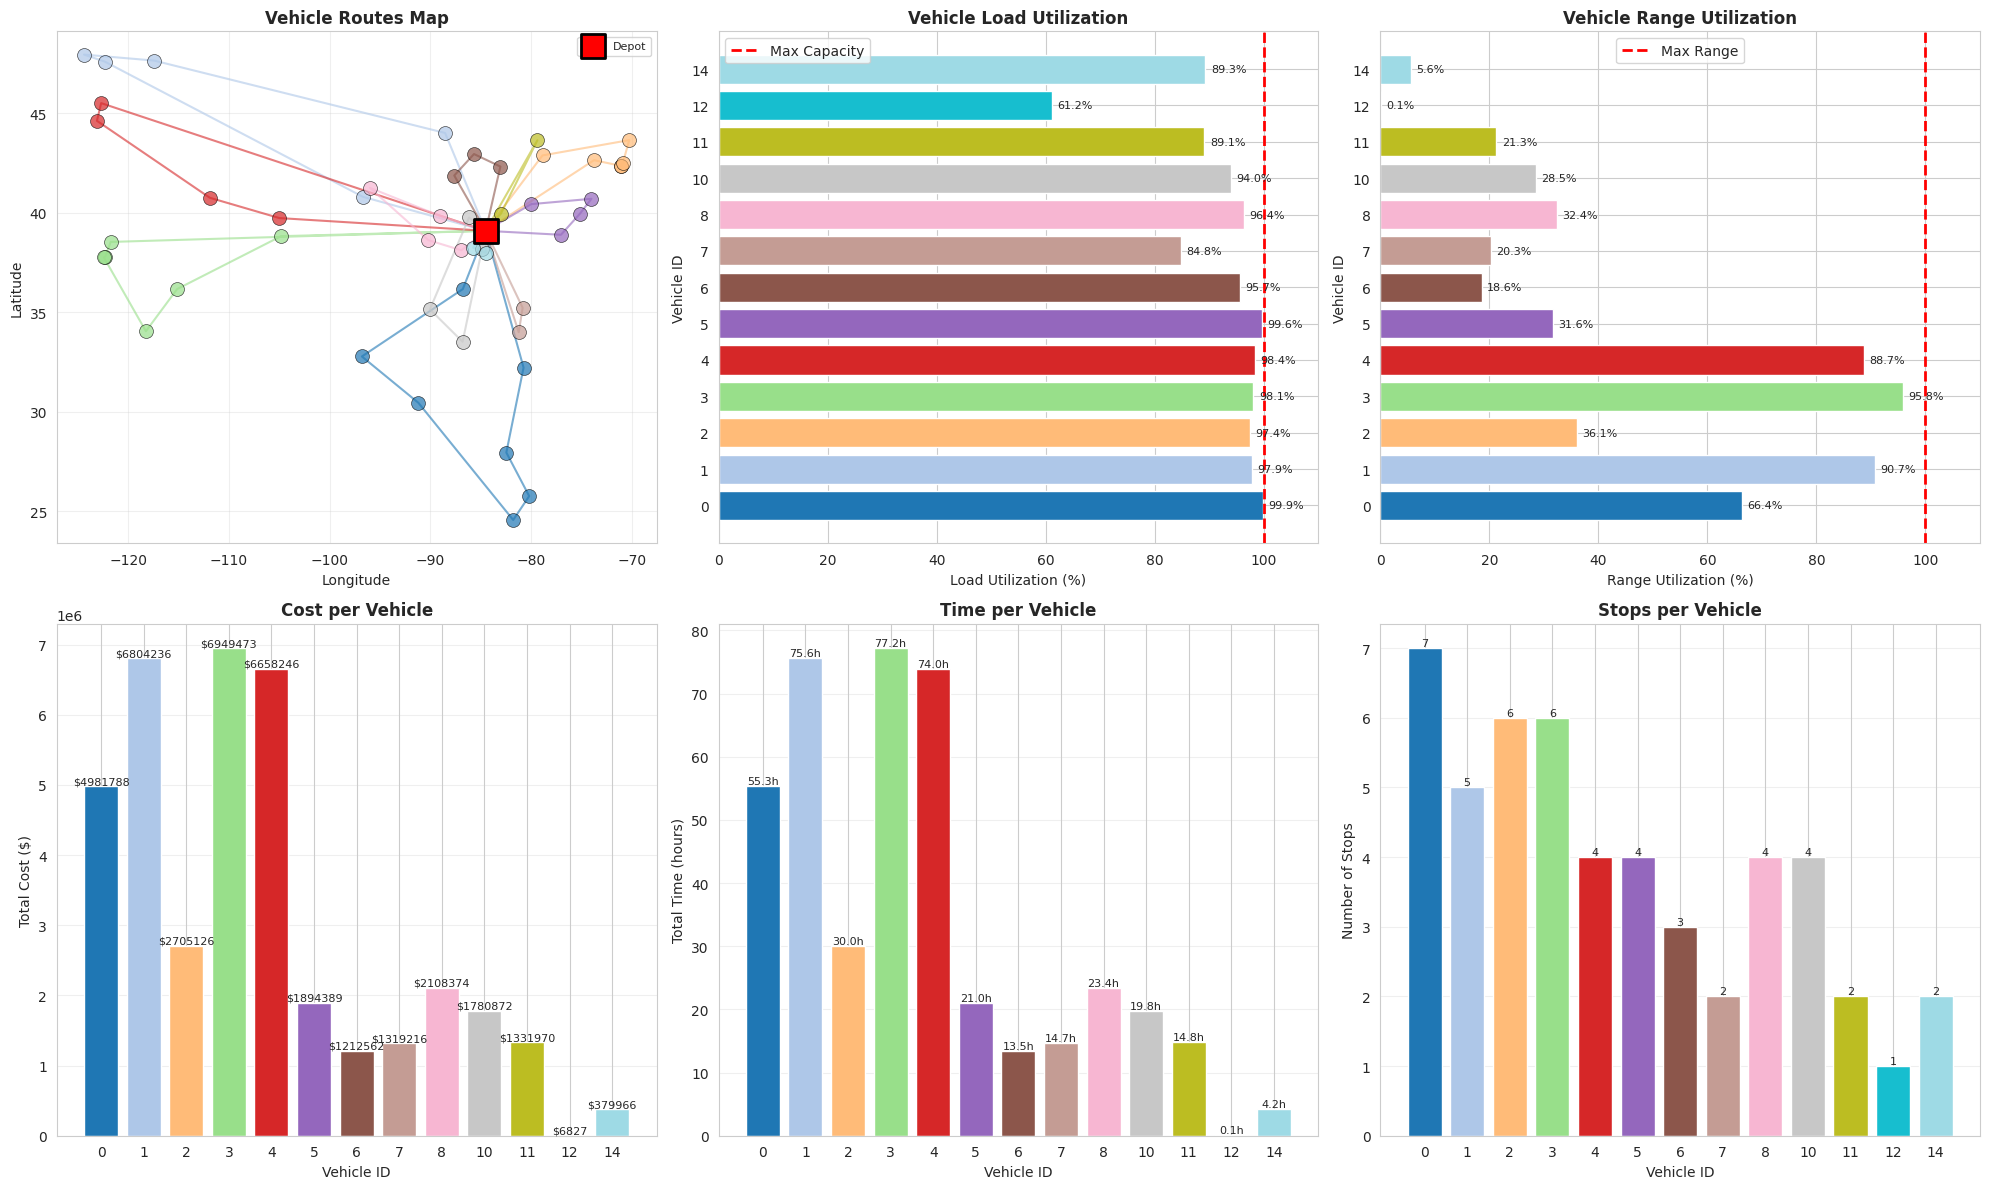



Tables saved to CSV files in: /content/CVRP_Sol
  - route_summary.csv
  - detailed_stops.csv
  - vehicle_specs.csv
  - cvrp_solution.png


In [14]:
# Setting first solution heuristic and search metaheuristic.
search_parameters = pywrapcp.DefaultRoutingSearchParameters()
search_parameters.first_solution_strategy = (
    routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
)
search_parameters.local_search_metaheuristic = (
    routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
)
search_parameters.time_limit.FromSeconds(5)

# Solve the problem.
solution = routing.SolveWithParameters(search_parameters)

# --- Define save directory ---
save_directory = '/content/CVRP_Sol'
os.makedirs(save_directory, exist_ok=True)

if solution:
    # Original output
    print_solution(data, manager, routing, solution)

    # Create tables
    routes_df, visits_df = create_solution_tables(data, manager, routing, solution)
    vehicle_specs_df = create_vehicle_summary_table(data)

    # Display tables
    print("\n\nVEHICLE SPECIFICATIONS:")
    display(vehicle_specs_df)

    print("\n\nROUTE SUMMARY:")
    display(routes_df)

    print("\n\nDETAILED STOPS (first 20 rows):")
    display(visits_df.head(20))

    # Print summary statistics
    print_summary_statistics(routes_df)

    # Create visualizations
    fig = visualize_routes(data, visits_df, routes_df)
    plt.savefig(os.path.join(save_directory, 'cvrp_solution.png'), dpi=300, bbox_inches='tight')
    plt.show()

    # Save tables to CSV
    routes_df.to_csv(os.path.join(save_directory, 'route_summary.csv'), index=False)
    visits_df.to_csv(os.path.join(save_directory, 'detailed_stops.csv'), index=False)
    vehicle_specs_df.to_csv(os.path.join(save_directory, 'vehicle_specs.csv'), index=False)

    print(f"\n\nTables saved to CSV files in: {save_directory}")
    print("  - route_summary.csv")
    print("  - detailed_stops.csv")
    print("  - vehicle_specs.csv")
    print("  - cvrp_solution.png")